Dữ liệu phân tích Node:
   User  PageRank  Betweenness      LCC  Community
  Alice  0.226611     0.252747 0.057143          0
    Bob  0.134933     0.060440 0.500000          0
  Frank  0.116725     0.120879 0.083333          2
    Eve  0.109218     0.082418 0.000000          2
 Ganesh  0.106311     0.093407 0.000000          2
Charlie  0.067346     0.000000 1.000000          0
  Oscar  0.066667     0.000000 0.000000          3
 Naveen  0.066667     0.000000 0.000000          3
  Peggy  0.028963     0.032967 0.000000          1
Quentin  0.022309     0.000000 0.000000          1
  Heidi  0.014250     0.000000 0.500000          2
   Judy  0.010000     0.000000 0.000000          0
   Ivan  0.010000     0.000000 0.000000          0
  David  0.010000     0.000000 0.000000          0
  Grace  0.010000     0.000000 0.500000          2


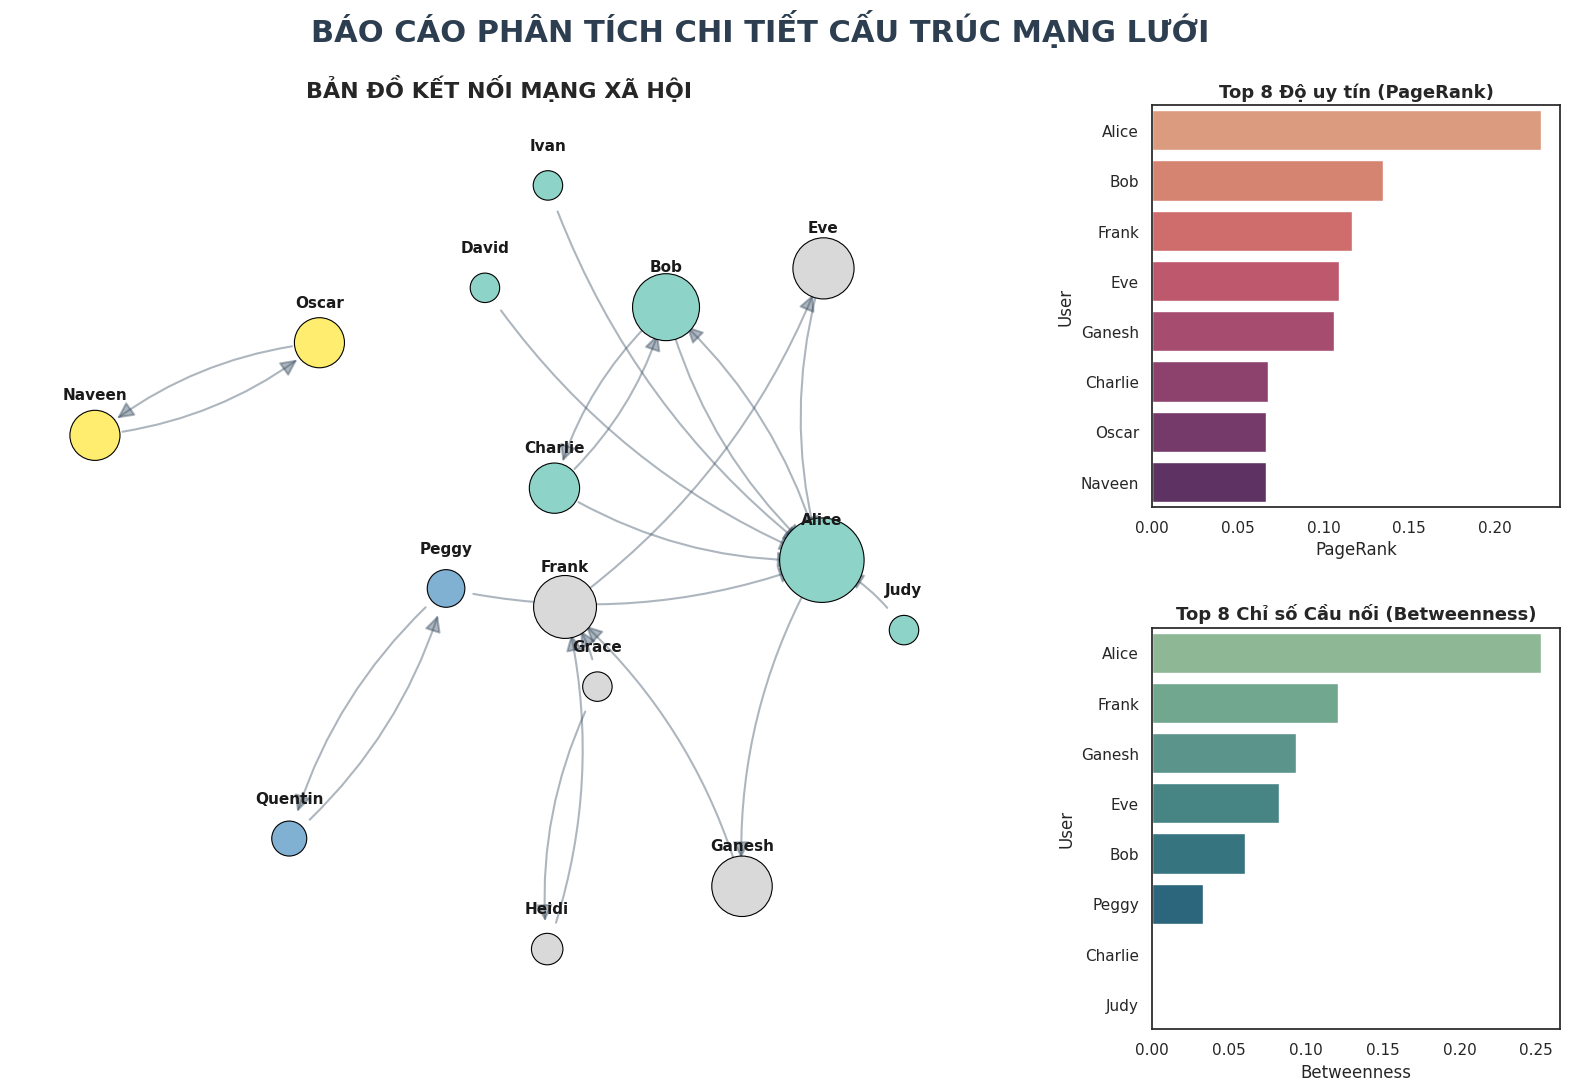

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from community import community_louvain

# --- 1. KHỞI TẠO ĐỒ THỊ ---
def create_social_graph():
    G = nx.DiGraph()
    edges = [
        ("Bob", "Alice"), ("Charlie", "Alice"), ("David", "Alice"),
        ("Eve", "Alice"), ("Ivan", "Alice"), ("Judy", "Alice"),
        ("Alice", "Bob"), ("Bob", "Charlie"), ("Charlie", "Bob"),
        ("Frank", "Eve"), ("Grace", "Frank"), ("Heidi", "Frank"), ("Grace", "Heidi"),
        ("Alice", "Ganesh"), ("Ganesh", "Frank"),
        ("Naveen", "Oscar"), ("Oscar", "Naveen"),
        ("Peggy", "Quentin"), ("Quentin", "Peggy"), ("Peggy", "Alice")
    ]
    G.add_edges_from(edges)
    return G

# --- 2. TÍNH TOÁN THÔNG SỐ ---
def get_analytics(G):
    # Tính PageRank (Độ uy tín)
    pagerank = nx.pagerank(G)
    # Tính Betweenness (Cầu nối)
    betweenness = nx.betweenness_centrality(G)
    # Tính LCC (Hệ số gom cụm)
    lcc = nx.clustering(G)
    # Phân cụm cộng đồng Louvain
    partition = community_louvain.best_partition(G.to_undirected())

    data = []
    for node in G.nodes():
        data.append({
            "User": node,
            "PageRank": pagerank[node],
            "Betweenness": betweenness[node],
            "LCC": lcc[node],
            "Community": partition[node]
        })
    return pd.DataFrame(data), partition

# --- 3. VẼ DASHBOARD TỔNG HỢP ---
def draw_dashboard(G, df, partition):
    sns.set_theme(style="white")
    fig = plt.figure(figsize=(20, 12))
    grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3)

    # --- Biểu đồ A: Sơ đồ mạng lưới (Khắc phục hình ảnh bị rối) ---
    ax_main = fig.add_subplot(grid[:, 0:2])

    # Tăng tham số k để các node đẩy nhau ra xa hơn, tránh dính chùm
    pos = nx.spring_layout(G, k=1.8, iterations=100, seed=42)

    node_sizes = [df.loc[df['User'] == n, 'PageRank'].values[0] * 15000 + 300 for n in G.nodes()]
    colors = [partition[n] for n in G.nodes()]

    # Vẽ cạnh có độ cong (rad=0.15) để thấy rõ luồng 2 chiều
    nx.draw_networkx_edges(
        G, pos, ax=ax_main,
        alpha=0.4,
        edge_color='#34495e',
        connectionstyle="arc3,rad=0.15",
        arrowstyle='-|>', # Kiểu mũi tên đặc
        arrowsize=25,     # Kích thước mũi tên
        arrows=True,      # Bắt buộc hiện mũi tên
        width=1.5,        # Độ dày của nét vẽ
        min_source_margin=20, # Khoảng cách từ gốc
        min_target_margin=20  # Khoảng cách đến đầu mũi tên (giúp hiện rõ đầu nhọn)
    )

    # 3. VẼ NODE
    nx.draw_networkx_nodes(
        G, pos, ax=ax_main,
        node_size=node_sizes,
        node_color=colors,
        cmap=plt.cm.Set3,
        edgecolors='black',
        linewidths=0.8
    )

    # Đẩy nhãn lên phía trên node một khoảng để không bị đè chữ
    label_pos = {k: [v[0], v[1] + 0.08] for k, v in pos.items()}
    nx.draw_networkx_labels(G, label_pos, ax=ax_main, font_size=11, font_weight="bold")

    ax_main.set_title("BẢN ĐỒ KẾT NỐI MẠNG XÃ HỘI", fontsize=16, fontweight='bold')
    ax_main.axis('off')

    # --- Biểu đồ B: PageRank ---
    ax_bar1 = fig.add_subplot(grid[0, 2])
    top_pr = df.sort_values("PageRank", ascending=False).head(8)
    sns.barplot(data=top_pr, x="PageRank", y="User", hue="User", palette="flare", ax=ax_bar1, legend=False)
    ax_bar1.set_title("Top 8 Độ uy tín (PageRank)", fontsize=13, fontweight='bold')

    # --- Biểu đồ C: Betweenness Centrality ---
    ax_bar2 = fig.add_subplot(grid[1, 2])
    top_bt = df.sort_values("Betweenness", ascending=False).head(8)
    sns.barplot(data=top_bt, x="Betweenness", y="User", hue="User", palette="crest", ax=ax_bar2, legend=False)
    ax_bar2.set_title("Top 8 Chỉ số Cầu nối (Betweenness)", fontsize=13, fontweight='bold')

    plt.suptitle("BÁO CÁO PHÂN TÍCH CHI TIẾT CẤU TRÚC MẠNG LƯỚI", fontsize=22, y=.96, fontweight='bold', color='#2c3e50')
    plt.show()

# --- 4. CHƯƠNG TRÌNH CHÍNH ---
if __name__ == "__main__":
    # 1. Tạo đồ thị
    twitter_graph = create_social_graph()

    # 2. Phân tích dữ liệu
    analysis_df, node_partition = get_analytics(twitter_graph)

    # 3. In bảng dữ liệu ra Console (tùy chọn)
    print("Dữ liệu phân tích Node:")
    print(analysis_df.sort_values("PageRank", ascending=False).to_string(index=False))

    # 4. Vẽ Dashboard đồ họa
    draw_dashboard(twitter_graph, analysis_df, node_partition)